<a href="https://colab.research.google.com/github/fares-works/Sales-Strategy-Optimization/blob/main/Sales-Strategy-Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analyst Professional Practical Exam Submission

**You can use any tool that you want to do your analysis and create visualizations. Use this template to write up your summary for submission.**

You can use any markdown formatting you wish. If you are not familiar with Markdown, read the [Markdown Guide](https://s3.amazonaws.com/talent-assets.datacamp.com/Markdown+Guide.pdf) before you start.


## 📝 Task List

Your written report should include written text summaries and graphics of the following:
- Data validation:   
  - Describe validation and cleaning steps for every column in the data
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Definition of a metric for the business to monitor  
  - How should the business use the metric to monitor the business problem
  - Can you estimate initial value(s) for the metric based on the current data
- Final summary including recommendations that the business should undertake

*Start writing report here..*

# ***1- Data validation and cleaning***

---





In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
# Load the data
df = pd.read_csv("product_sales.csv") # Assuming your file is named this

# Get a first look at data types and non-null counts
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            13926 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB
None


In [ ]:

# Get summary statistics for numerical columns
print(df.describe())


               week       nb_sold       revenue  years_as_customer  \
count  15000.000000  15000.000000  13926.000000       15000.000000   
mean       3.098267     10.084667     93.934943           4.965933   
std        1.656420      1.812213     47.435312           5.044952   
min        1.000000      7.000000     32.540000           0.000000   
25%        2.000000      9.000000     52.470000           1.000000   
50%        3.000000     10.000000     89.500000           3.000000   
75%        5.000000     11.000000    107.327500           7.000000   
max        6.000000     16.000000    238.320000          63.000000   

       nb_site_visits  
count    15000.000000  
mean        24.990867  
std          3.500914  
min         12.000000  
25%         23.000000  
50%         25.000000  
75%         27.000000  
max         41.000000  


In [ ]:

# Check for any missing values in any column
print(df.isnull().sum())

week                    0
sales_method            0
customer_id             0
nb_sold                 0
revenue              1074
years_as_customer       0
nb_site_visits          0
state                   0
dtype: int64


**revenue column has missing values ❌**

In [ ]:
print(df['week'].unique())
print(df['sales_method'].unique())

[2 6 5 4 3 1]
['Email' 'Email + Call' 'Call' 'em + call' 'email']


**there are different spellings for the sales method ❌**

In [ ]:
# Example fix
df['sales_method'] = df['sales_method'].replace('email', 'Email')
df['sales_method'] = df['sales_method'].replace('em + call', 'Email + Call')

**sales method spelling fixed ✅**

In [ ]:
print(df[df['revenue'].isnull()]['sales_method'].value_counts())

sales_method
Email           544
Email + Call    349
Call            181
Name: count, dtype: int64


In [ ]:
print(df['sales_method'].value_counts())

sales_method
Email           7466
Call            4962
Email + Call    2572
Name: count, dtype: int64


In [ ]:
# Calculate the percentage of missing revenue for EACH sales method
missing_by_group = df.groupby('sales_method')['revenue'].apply(lambda x: x.isnull().mean() * 100)

print(missing_by_group.to_string())

sales_method
Call             3.647723
Email            7.286365
Email + Call    13.569207


**the missing values are biased(13.5% of Email + Call are missing compared to 7.2% for email only and 3.6% for call only ) but we will drop it anyway because revenue is what we care about the most❗**

In [ ]:
df = df.dropna(subset=['revenue'])

In [ ]:
print(df[df['revenue'].isnull()]['sales_method'].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
print(df.isnull().sum())

week                 0
sales_method         0
customer_id          0
nb_sold              0
revenue              0
years_as_customer    0
nb_site_visits       0
state                0
dtype: int64


In [ ]:
print(f"Total rows: {len(df)}")
print(f"Unique customers: {df['customer_id'].nunique()}")

Total rows: 13926
Unique customers: 13926


**revenue missing values fixed ✅**

In [ ]:
print(df[df['nb_sold'] <= 0])

Empty DataFrame
Columns: [week, sales_method, customer_id, nb_sold, revenue, years_as_customer, nb_site_visits, state]
Index: []


In [ ]:
print(df[df['years_as_customer'] < 0])

Empty DataFrame
Columns: [week, sales_method, customer_id, nb_sold, revenue, years_as_customer, nb_site_visits, state]
Index: []


In [ ]:
print(df[df['revenue'] <= 0])

Empty DataFrame
Columns: [week, sales_method, customer_id, nb_sold, revenue, years_as_customer, nb_site_visits, state]
Index: []


In [ ]:
print(df[df['nb_site_visits'] <= 0])

Empty DataFrame
Columns: [week, sales_method, customer_id, nb_sold, revenue, years_as_customer, nb_site_visits, state]
Index: []


#***Data validation and cleaning ✅***

In [ ]:
df

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois
5,6,Call,6489e678-40f2-4fed-a48e-d0dff9c09205,13,65.01,10,24,Mississippi
6,4,Email,eb6bd5f1-f115-4e4b-80a6-5e67fcfbfb94,11,113.38,9,28,Georgia
...,...,...,...,...,...,...,...,...
14994,4,Email,56f02e26-3633-427d-8c4e-f45f00afa787,11,109.36,3,25,Ohio
14995,4,Call,17267b41-d048-4346-8b90-7f787690a836,10,50.82,0,22,Pennsylvania
14996,5,Call,09e10d6f-4508-4b27-895e-4db11ce8302b,10,52.33,1,27,Kansas
14997,1,Call,839653cb-68c9-48cb-a097-0a5a3b2b298b,7,34.87,4,22,West Virginia


# ***2- Exploratory Analysis***

---



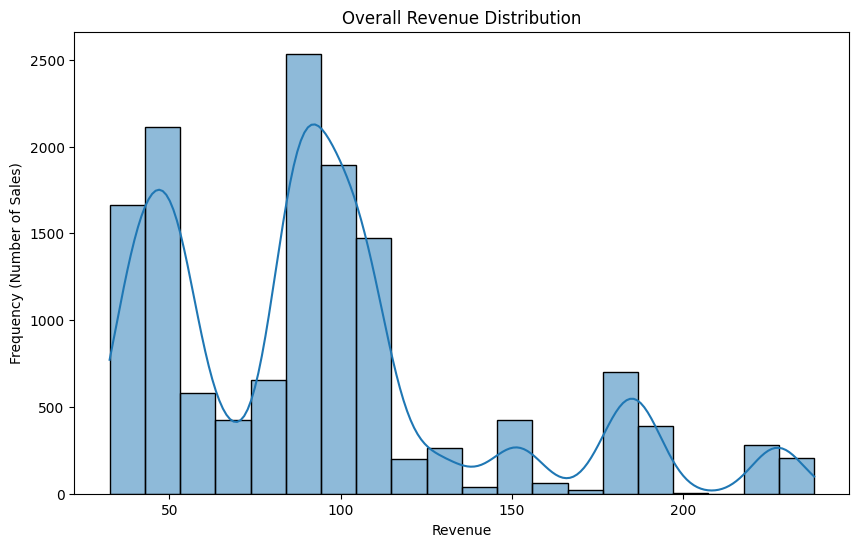

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['revenue'], bins=20, kde=True)
plt.title('Overall Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency (Number of Sales)')
plt.show()

the spread of revenue is more toward 30 - 120

/tmp/ipython-input-157061069.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sales_method', data=df,


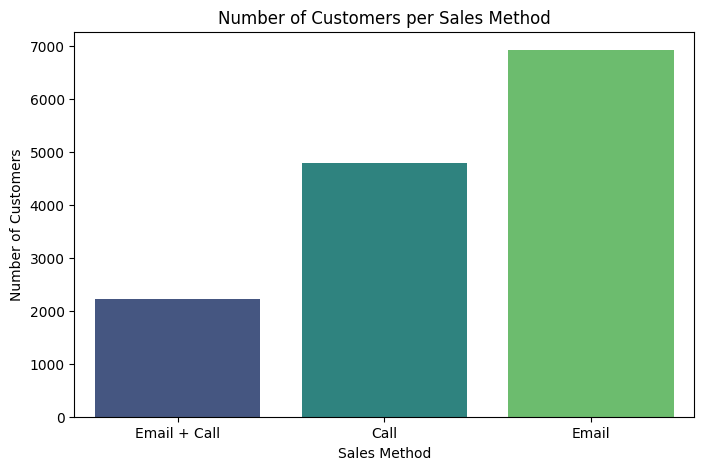

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sales_method', data=df,
    palette='viridis')
plt.title('Number of Customers per Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Number of Customers')
plt.show()

**the "email only" method has more customers than the other methods 📊**

/tmp/ipython-input-494179065.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sales_method', y='revenue', data=df,


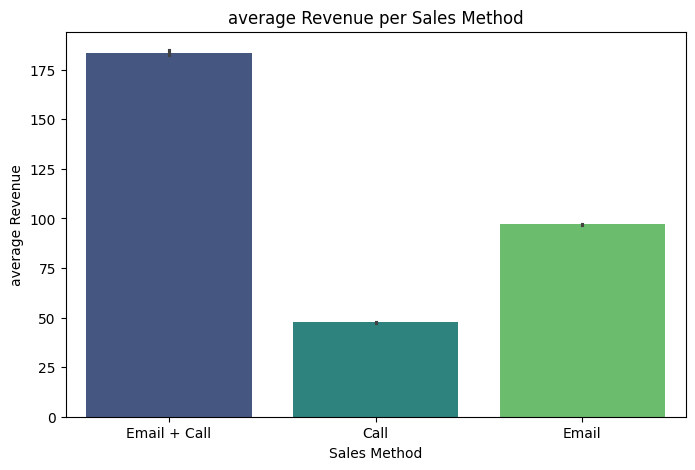

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='sales_method', y='revenue', data=df,
    palette='viridis')
plt.title('average Revenue per Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Average Revenue')
plt.show()

**even though the "email only" method has more customers.. the "email + call" method has more revenue❗ maybe this is beacuse the "email only" method is easier and it has been sent by more volume❓**

/tmp/ipython-input-3989669857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sales_method', y='revenue', data=df,


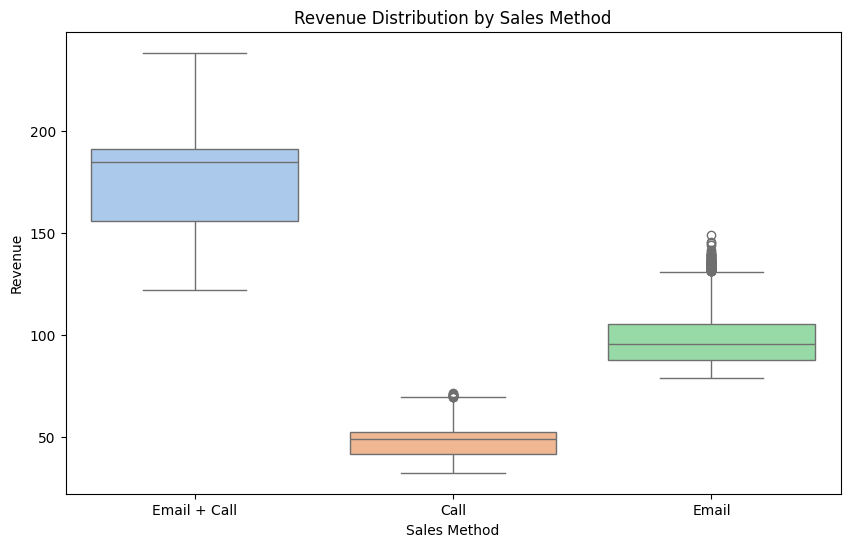

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='sales_method', y='revenue', data=df,
    palette='pastel')
plt.title('Revenue Distribution by Sales Method')
plt.xlabel('Sales Method')
plt.ylabel('Revenue')
plt.show()

**more revenue and more distribution for the "email + call" method**

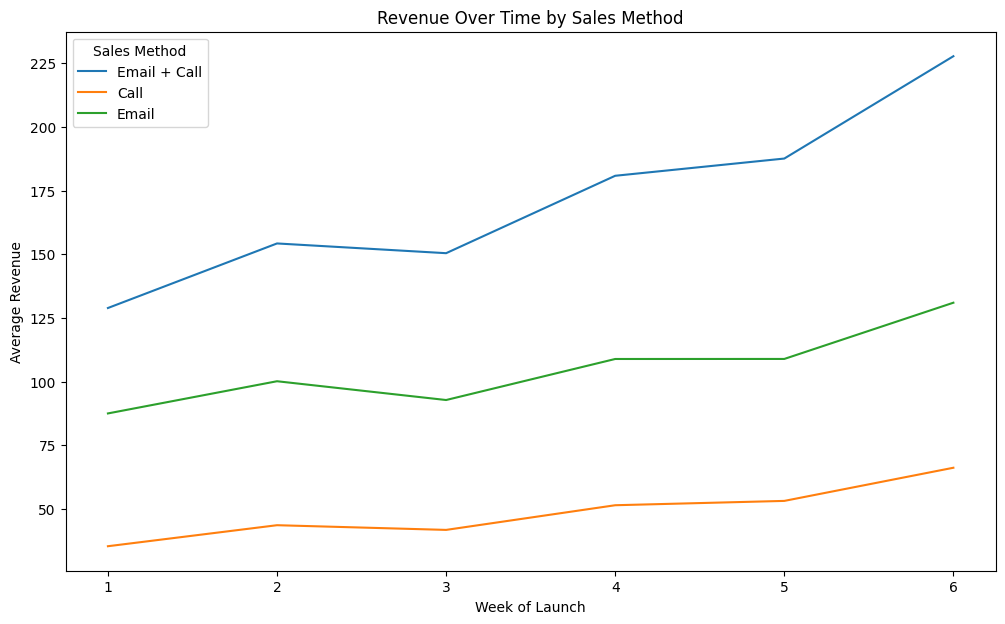

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(x='week', y='revenue', hue='sales_method', data=df, errorbar=None) # errorbar=None shows the simple average
plt.title('Revenue Over Time by Sales Method')
plt.xlabel('Week of Launch')
plt.ylabel('Average Revenue')
plt.legend(title='Sales Method')
plt.show()

**and its getting better every week 😀**

---



My analysis of the data revealed several key findings in response to the sales rep's questions:

Customer Count: **The 'Email' method was used on the most customers (6,922)**, while **'Email + Call' was used on the fewest (2,223).**

Revenue Spread: **The 'Email + Call' method generated the highest average revenue (approx. $183)** and the widest revenue spread, indicating it has the highest potential for large sales.
the "call" method had the lowest average revenue  (approx. 47)

# **Exploratory Analysis ✅**

---



# **3- Definition of a metric for the business to monitor**
The sales rep noted that some methods take more team time. Therefore, looking at revenue alone is misleading.

Metric: Sales Efficiency (Revenue per Minute)
I defined a new metric, "Sales Efficiency," calculated as Average Revenue / Time Cost in Minutes.[link text](https://)

In [ ]:
# Calculate the average revenue for each sales method
avg_revenue = df.groupby('sales_method')['revenue'].mean().reset_index()

avg_revenue.columns = ['sales_method', 'average_revenue']

print(avg_revenue)

   sales_method  average_revenue
0          Call        47.597467
1         Email        97.127684
2  Email + Call       183.651233


In [ ]:
# Time costs in minutes, based on the project brief
# Email: "very little work" I will estimate 3 minutes.
# Call: "around thirty minutes" 30 minutes
# Email + Call: "call around ten minutes" 10 minutes + 3

time_costs = {
    'Email': 3,
    'Call': 30,
    'Email + Call': 13
}

# Convert this to a DataFrame
time_df = pd.DataFrame(time_costs.items(), columns=['sales_method', 'time_cost_min'])

print(time_df)

   sales_method  time_cost_min
0         Email              3
1          Call             30
2  Email + Call             13


In [ ]:
# Merge the average revenue and time cost data
metric_df = pd.merge(avg_revenue, time_df, on='sales_method')

print(metric_df)

   sales_method  average_revenue  time_cost_min
0          Call        47.597467             30
1         Email        97.127684              3
2  Email + Call       183.651233             13


In [ ]:
# Calculate the "Revenue per Minute" metric
metric_df['revenue_per_minute'] = metric_df['average_revenue'] / metric_df['time_cost_min']

print(metric_df.sort_values(by='revenue_per_minute', ascending=False))

   sales_method  average_revenue  time_cost_min  revenue_per_minute
1         Email        97.127684              3           32.375895
2  Email + Call       183.651233             13           14.127018
0          Call        47.597467             30            1.586582


/tmp/ipython-input-2778831689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sales_method', y='revenue_per_minute', data=metric_df,


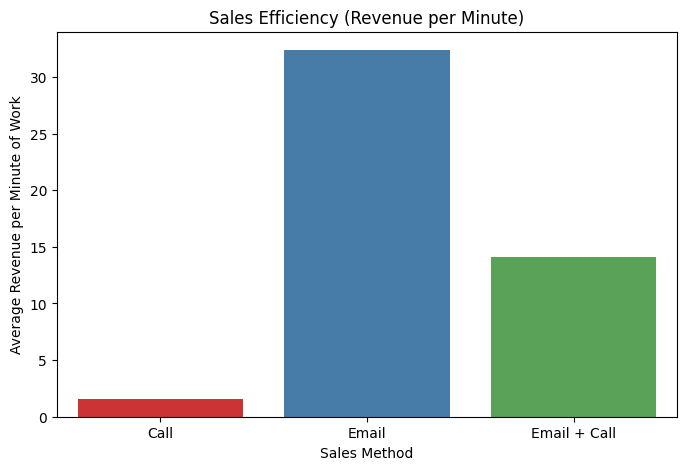

In [ ]:
# Plot the new metric
plt.figure(figsize=(8, 5))
sns.barplot(x='sales_method', y='revenue_per_minute', data=metric_df,
    palette='Set1')
plt.title('Sales Efficiency (Revenue per Minute)')
plt.xlabel('Sales Method')
plt.ylabel('Average Revenue per Minute of Work')
plt.show()

# While the 'Email' method is technically the most efficient (highest revenue per minute), my recommendation is still to use the 'Email + Call' method as the primary sales strategy.

The 'Email' method is low-cost but also low-impact. As seen in the box plot, its average revenue is almost half of 'Email + Call' and it shows no growth over time in the line chart.

The 'Email + Call' method is the most effective. It generates the highest average revenue ($183), has the highest revenue ceiling (from the box plot), and is the only method showing consistent growth week over week. It offers the best balance of efficiency and high performance.

# **Definition of a metric for the business to monitor ✅**

# **Final summary including recommendations that the business should undertake**

---

Recommendations:

Adopt 'Email + Call': The business should adopt the 'Email + Call' method as the primary sales strategy.
use "email only" as the secondary and not fully give up on it

# **done ✅🎉**

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation